# <h2 style='color:grey' align='center'>**Chest X-Ray Pneumonia Classification: Scratch CNN** 🫁</h2>

### **CAP 4630 - Intro to Artificial Intelligence | Final Project**

**Team Member:** Alexander Moller

**Dataset:** [Chest X-Ray Pneumonia Balanced Dataset](https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/data)

**Split:** 80% Train | 10% Validation | 10% Test

<div style="border-radius:12px; padding: 20px; font-size:115%; text-align:left">

<h2 align="left">About the Project</h2>

We classify chest X-ray images into two classes:

- **NORMAL** 🟢 — Healthy lungs
- **PNEUMONIA** 🔴 — Lungs showing pneumonia infection

We compare **Three iteration approaches**:

1. **Model 1: Scratch CNN** — A Sequential CNN with Conv2D, MaxPooling2D, Dense, and Sigmoid activation layer. Establishing a baseline model to identify performance

2. **Model 2: Scratch CNN with Data Augmentation** — A Sequential CNN similar to Model 1, addressing issues such as overfitting, through adding data augmentation with random transformations (rotation, width/height shifts, and horizontal flips).

3. **Model 3: Scratch CNN with Data Augmentation & Batch Normilization** - Advanced approach from Model 2, to improve stablility, adding batch normilization, increasing Dropout rate: 0.2 -> 0.5, and a reduced learning rate on plateau when the validation loss stops improving

</div>

<h4 style="color:purple">Step 1: Mount Google Drive & Unzip the Dataset 📂</h4>

In [3]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/final_dataset_80_10_10.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/xray_data')

dataset = '/content/xray_data/final_dataset_80_10_10'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h4 style="color:purple">Step 2: Import Necessary Libraries ☝️
</h4>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
import os

<h4 style="color:purple"> Step 3: Define Standard Helper functions 🛠️<h4>

In [5]:

def image_plt(images, labels):
  plt.figure(figsize = (15,8))
  for i in range(1,11):
    plt.subplot(2, 5, i)
    plt.imshow(images[i-1])
    plt.title('Label: ' + str(labels[i-1]))
    plt.show()

def accuracy_function(labels_actual, labels_predicted):
  accuracy = np.sum(labels_actual == labels_predicted) / len(labels_actual) * 100
  return accuracy

def plot_curve(accuracy_train, loss_train, title='Training'):
    epochs = np.arange(loss_train.shape[0])
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy_train)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title + ' Accuracy')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss_train)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title + ' Loss')
    plt.show()

<h4 style="color:purple">Step 4: Load & Preprocess Images from Dataset Splits 🗃️
</h4>

Iterate through each class folder and resize images to 224 x 224, and organizing them into NumPy arrays for an 80:10:10 split

In [6]:
from PIL import Image

#224 by 224 image size
IMG_size = (224,224)

#create labels
classes = np.array(['NORMAL', 'PNEUMONIA'])

def load_split(split):
    images, labels = [], []
    for label, class_name in enumerate(classes):
        class_path = os.path.join(dataset, split, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB').resize(IMG_size)
                images.append(np.array(img))
                labels.append(label)
            except:
                pass
    return np.array(images), np.array(labels)

#load split from subfolders
x_train, y_train = load_split('train')
x_val,   y_val   = load_split('val')
x_test,  y_test  = load_split('test')

<h4 style="color:purple">Step 5: Identify Specifics of Dataset Splits 🗃️
</h4>

In [7]:
#identify shape of segments in a 80:10:10 split
print(f"Training shape (80%): ", {x_train.shape})
print(f"Validation Shape (10%): ", {x_val.shape})
print(f"Testing Shape (10%): ", {x_test.shape})

Training shape (80%):  {(6824, 224, 224, 3)}
Validation Shape (10%):  {(852, 224, 224, 3)}
Testing Shape (10%):  {(854, 224, 224, 3)}


<h4 style="color:purple">Step 6: Shuffle, Visualize & Scale Training Data 🎲</h4>

Randomly shuffles the training set and scaling all values to [0,1], then converting labels to encoded binary matrices.

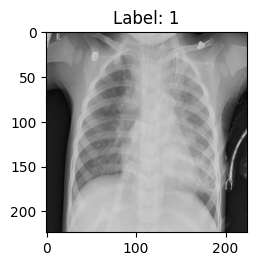

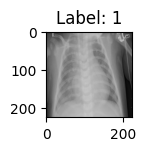

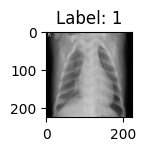

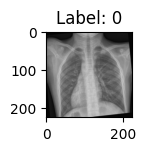

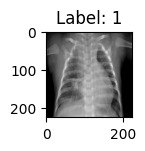

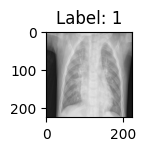

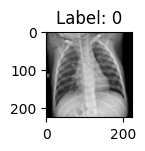

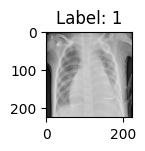

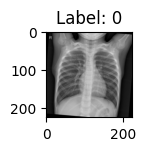

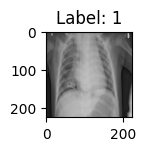

In [8]:
#shuffle training indicies and scale data
num_train_img = x_train.shape[0]
train_ind_s = np.random.permutation(num_train_img)
x_train = x_train[train_ind_s]
y_train = y_train[train_ind_s]

#load first ten images with labels
image_plt(x_train[0:10], y_train[0:10])

#scale images
x_train = x_train.astype('float32') / 255
x_val   = x_val.astype('float32') / 255
x_test  = x_test.astype('float32') / 255

#binary class matrixes
y_train_c = to_categorical(y_train, 2)
y_val_c   = to_categorical(y_val, 2)
y_test_c  = to_categorical(y_test, 2)

#<h2 style='color:#1976d2'>**Part 1: Baseline CNN** 📂</h2>

<h4 style="color:purple">Step 7: Model 1 — Baseline Scratch CNN Training & Performance 📊</h4>

Creating and training a scratch CNN model using two convolutional layers, 128-unit dense layer, and a sigmoid activation layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,755,937 (98.25 MB)

 Trainable params: 25,755,937 (98.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - acc: 0.8293 - loss: 0.4931
Epoch 1: val_loss improved from None to 0.14797, saving model to /content/drive/MyDrive/model_a_XRAY1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_a_XRAY1.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 52s 175ms/step - acc: 0.8998 - loss: 0.2680 - val_acc: 0.9531 - val_loss: 0.1480
Epoch 2/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.9607 - loss: 0.1139
Epoch 2: val_loss improved from 0.14797 to 0.09289, saving model to /content/drive/MyDrive/model_a_XRAY1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_a_XRAY1.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - acc: 0.9604 - loss: 0.1100 - val_acc: 0.9707 - val_loss: 0.0929
Epoch 3/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - acc: 0.9694 - loss: 0.0889
Epoch 3: val_loss did not improve from 0.09289
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - acc: 0.9682 - loss: 0.0855 - val_acc: 0.9671 - val_loss: 0.1000

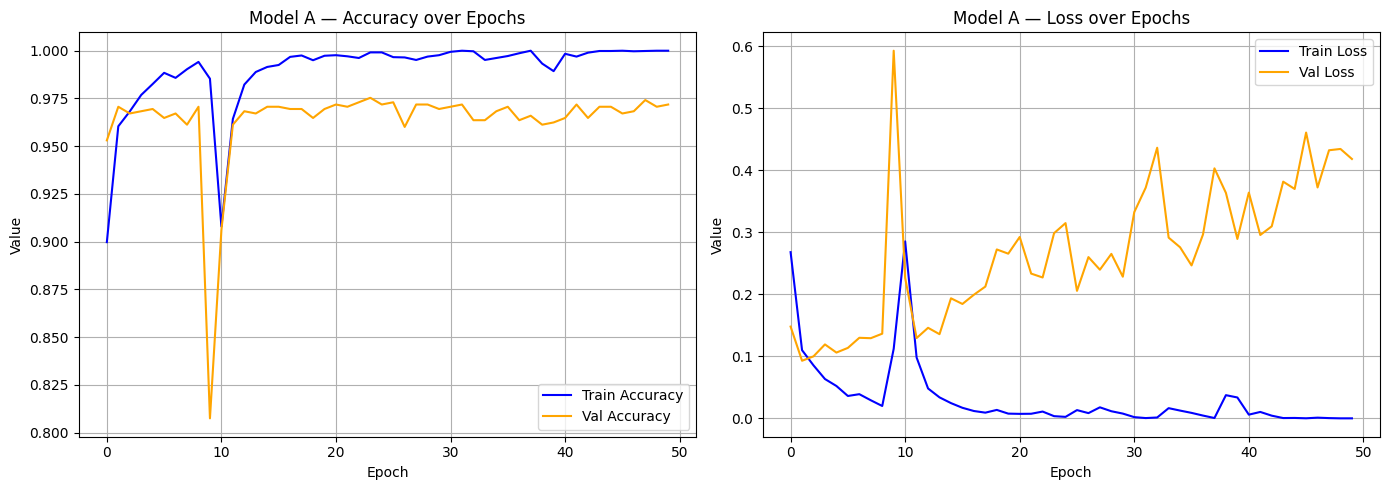

In [9]:
#defining model #1

from keras.callbacks import ModelCheckpoint

#layer 1
model_a = Sequential()
model_a.add(Conv2D(32, (3, 3), padding = 'same', input_shape = x_train.shape[1:]))
model_a.add(Activation('relu'))
model_a.add(Conv2D(32, (3, 3), padding = 'same'))
model_a.add(Activation('relu'))
model_a.add(MaxPooling2D(pool_size=(2, 2)))
#layer 2
model_a.add(Conv2D(64, (3, 3), padding = 'same'))
model_a.add(Activation('relu'))
model_a.add(Conv2D(64, (3, 3), padding = 'same'))
model_a.add(Activation('relu'))
model_a.add(MaxPooling2D(pool_size = (2,2)))

#flatten
model_a.add(Flatten())
model_a.add(Dense(128))
model_a.add(Dropout(0.5))
model_a.add(Dense(1))
model_a.add(Activation('sigmoid'))

#summary
model_a.summary()

#create model checkpoint
save_path = '/content/drive/MyDrive/model_a_XRAY1.keras'
callbacks_save = ModelCheckpoint(save_path, monitor = 'val_loss', verbose = 1, save_best_only = True, save_freq = 'epoch')

#model
opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_a.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['acc'])

history = model_a.fit(x_train, y_train,
                      batch_size = 32,
                      epochs = 50,
                      verbose = 1,
                      validation_data = (x_val, y_val),
                      callbacks = [callbacks_save])

history_data = history.history
epochs = np.arange(len(history_data['acc']))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['acc'], color='blue', label='Train Accuracy')
plt.plot(epochs, history_data['val_acc'], color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model A — Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], color='blue', label='Train Loss')
plt.plot(epochs, history_data['val_loss'], color='orange', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model A — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

<h4 style="color:purple">Step 8: Model 1 — Evaluate the Model 📉</h4>

In [10]:
scorea = model_a.evaluate(x_test, y_test)
print('Total loss on test set: ', scorea[0])
print('Accuracy of test set: ', scorea[1])

score = model_a.evaluate(x_val, y_val)
print('Total loss on validation set: ', score[0])
print('Accuracy of validation set: ', score[1])

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - acc: 0.9508 - loss: 0.5671
Total loss on test set:  0.5670809149742126
Accuracy of test set:  0.9508196711540222
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9718 - loss: 0.4181
Total loss on validation set:  0.41814300417900085
Accuracy of validation set:  0.9718309640884399


<h4 style="color:purple">Step 9: Model 1 — Confusion Matrix, Accuracy, F1, Precision & Recall Scores ✅</h4>

Generates performance on the test set, with a threshold of 50%, and evaluates Model 1's classification using a confusion matrix, accuracy score, and a classification report that displays: precision, recall, f1-score, and support scores


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

The accuracy using the testing set:  0.9508196721311475

The confusion matrix using testing set: 
 [[404  19]
 [ 23 408]]


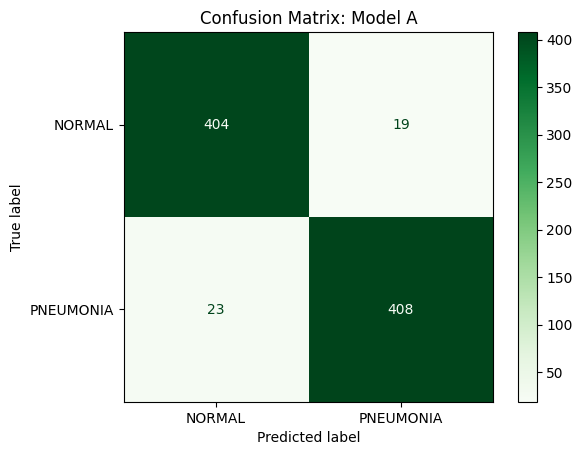


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.95      0.95       427
   PNEUMONIA       0.95      0.96      0.95       427

    accuracy                           0.95       854
   macro avg       0.95      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



In [11]:
#Defining confusion matrix, F1 score and recall for model 1

test_class1_prob = model_a.predict(x_test)

test_lab = (test_class1_prob > 0.5).astype("int32")


print('\nThe accuracy using the testing set: ', accuracy_score(test_lab,y_test))

conf_matx =confusion_matrix(test_lab,y_test)
print('\nThe confusion matrix using testing set: \n', conf_matx)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matx, display_labels=classes)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Model A')
plt.show()

#F1, Recall, Precision
print('\nClassification Report:')
print(classification_report(y_test, test_lab, target_names=classes))

<h4 style="color:purple">Step 10: Model 1 — Receiver Operating Characteristic (ROC) Curve </h4>

Plots the true positive rate against the false positive rate accross the threshold to determine model capability


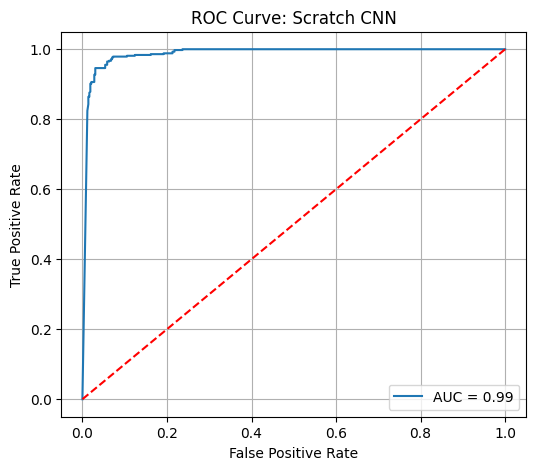

In [12]:
#model a
fpr_a, tpr_a, _ = roc_curve(y_test, test_class1_prob)
auc_a = auc(fpr_a, tpr_a)
plt.figure(figsize=(6, 5))
plt.plot(fpr_a, tpr_a, label=f'AUC = {auc_a:.2f}')
plt.plot([0, 1], [0, 1], color = 'r', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Scratch CNN')
plt.legend()
plt.grid(True)
plt.show()


#<h2 style='color:#1976d2'>**Part 2: CNN + Data Augmentation** 📝</h2>

<h4 style="color:purple">Step 11: Model 2 — Scratch CNN + Data Augmenation Training & Performance 🔎</h4>

Creating and training a scratch CNN model using two convolutional layers, 128-unit dense layer, and a sigmoid activation layer.

**Note:** The previous model showed signs of overfitting the data, so I added data augmentation to train the model on more similar images with rotation, width/height shifting, and horizontal flips.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,755,937 (98.25 MB)

 Trainable params: 25,755,937 (98.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - acc: 0.7530 - loss: 1.8288
Epoch 1: val_loss improved from None to 0.33871, saving model to /content/drive/MyDrive/model_b_XRAY2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_b_XRAY2.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 81s 365ms/step - acc: 0.8376 - loss: 0.6659 - val_acc: 0.8768 - val_loss: 0.3387
Epoch 2/50
  1/213 ━━━━━━━━━━━━━━━━━━━━ 31s 150ms/step - acc: 0.9688 - loss: 0.0629

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 0.33871
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9688 - loss: 0.0629 - val_acc: 0.8768 - val_loss: 0.3434
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - acc: 0.9073 - loss: 0.2259
Epoch 3: val_loss improved from 0.33871 to 0.21648, saving model to /content/drive/MyDrive/model_b_XRAY2.keras

Epoch 3: finished saving model to /content/drive/MyDrive/model_b_XRAY2.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 72s 337ms/step - acc: 0.9143 - loss: 0.2212 - val_acc: 0.9437 - val_loss: 0.2165
Epoch 4/50
  1/213 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - acc: 0.9375 - loss: 0.2148
Epoch 4: val_loss did not improve from 0.21648
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9375 - loss: 0.2148 - val_acc: 0.9354 - val_loss: 0.2249
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - acc: 0.9216 - loss: 0.2179
Epoch 5: val_loss did not improve from 0.21648
213/213 ━━━━━━━━━━━━━━━━━━━━ 72s 337ms/step - acc: 0.9290 - loss: 0.1960 - val_acc: 0.9038 - va

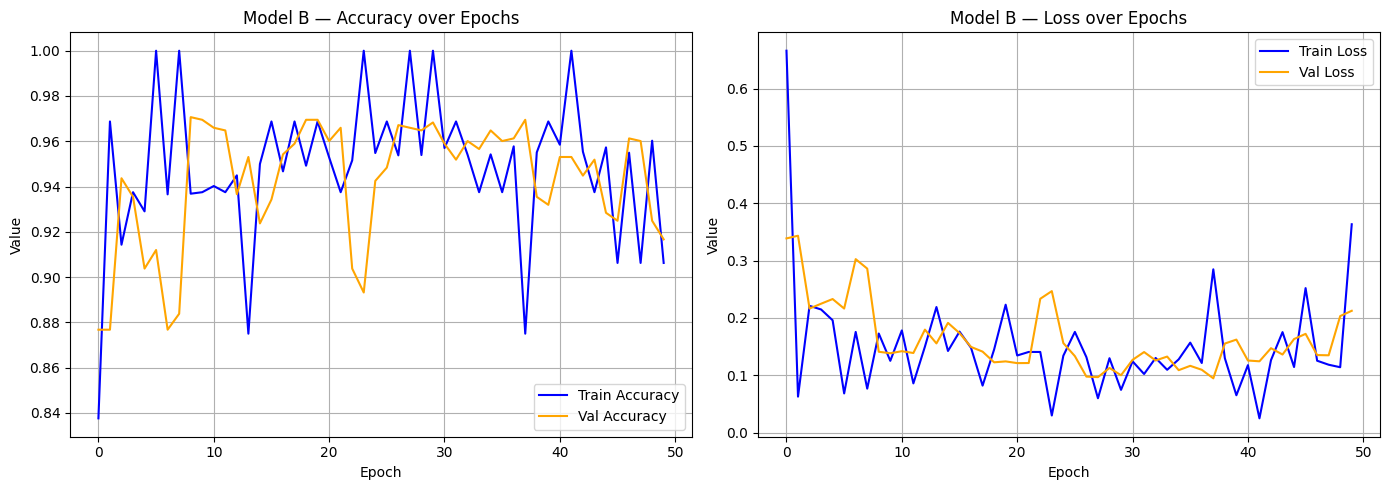

In [13]:
#defining model 2 with augmented images due to reduce overfitting

#layer 1
model_b = Sequential()
model_b.add(Conv2D(32, (3, 3), padding = 'same', input_shape = x_train.shape[1:]))
model_b.add(Activation('relu'))
model_b.add(Conv2D(32, (3, 3), padding = 'same'))
model_b.add(Activation('relu'))
model_b.add(MaxPooling2D(pool_size=(2, 2)))
#layer 2
model_b.add(Conv2D(64, (3, 3), padding = 'same'))
model_b.add(Activation('relu'))
model_b.add(Conv2D(64, (3, 3), padding = 'same'))
model_b.add(Activation('relu'))
model_b.add(MaxPooling2D(pool_size = (2,2)))

#flatten
model_b.add(Flatten())
model_b.add(Dense(128))
model_b.add(Dropout(0.5))
model_b.add(Dense(1))
model_b.add(Activation('sigmoid'))
#summary
model_b.summary()

save_path = '/content/drive/MyDrive/model_b_XRAY2.keras'
callbacks_save = ModelCheckpoint(save_path, monitor = 'val_loss', verbose = 1, save_best_only = True, save_freq = 'epoch')

opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_b.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['acc'])

train_datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True)

val_datagen = ImageDataGenerator()
train_datagen.fit(x_train)

history_b = model_b.fit(train_datagen.flow(x_train, y_train, batch_size=32),
                      steps_per_epoch=len(x_train) // 32,
                      epochs=50,
                      verbose=1,
                      validation_data=val_datagen.flow(x_val, y_val, batch_size=32),
                      callbacks=[callbacks_save])

history_data = history_b.history
epochs = np.arange(len(history_data['acc']))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['acc'], color='blue', label='Train Accuracy')
plt.plot(epochs, history_data['val_acc'], color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model B — Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], color='blue', label='Train Loss')
plt.plot(epochs, history_data['val_loss'], color='orange', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model B — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


<h4 style="color:purple">Step 12: Model 2 — Evaluate the Model 📑</h4>

In [14]:
scoreb = model_b.evaluate(x_test, y_test)
print('Total loss on test set: ', scoreb[0])
print('Accuracy of test set: ', scoreb[1])

score = model_b.evaluate(x_val, y_val)
print('Total loss on validation set: ', score[0])
print('Accuracy of validation set: ', score[1])

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.9192 - loss: 0.2406
Total loss on test set:  0.24056197702884674
Accuracy of test set:  0.9192037582397461
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9167 - loss: 0.2125
Total loss on validation set:  0.21254345774650574
Accuracy of validation set:  0.9166666865348816


<h4 style="color:purple">Step 13: Model 2 — Confusion Matrix, Accuracy, F1, Precision & Recall Scores 🎯</h4>

Runs the test set through Model 2 + data augmentation, applies a 50% threshold, and creates a confusion matrix alongside accuracy, precision, recall, and F1-score evaluations.

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

The accuracy using the testing set:  0.9192037470725996

The confusion matrix using testing set: 
 [[426  68]
 [  1 359]]


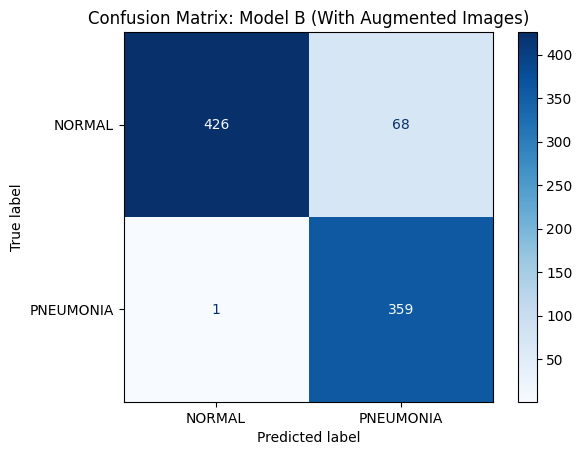


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      1.00      0.93       427
   PNEUMONIA       1.00      0.84      0.91       427

    accuracy                           0.92       854
   macro avg       0.93      0.92      0.92       854
weighted avg       0.93      0.92      0.92       854



In [15]:
#Defining confusion matrix, F1 score & recall for model 2

test_class2_prob = model_b.predict(x_test)

test_lab2 = (test_class2_prob > 0.5).astype("int32")


print('\nThe accuracy using the testing set: ', accuracy_score(test_lab2,y_test))

conf_matx =confusion_matrix(test_lab2,y_test)
print('\nThe confusion matrix using testing set: \n', conf_matx)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matx, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Model B (With Augmented Images)')
plt.show()

#F1, Recall, Precision
print('\nClassification Report:')
print(classification_report(y_test, test_lab2, target_names=classes))

<h4 style="color:purple">Step 14: Model 2 — Receiver Operating Characteristic (ROC) Curve </h4>

Plots the true positive rate against the false positive rate accross the threshold to determine model capability


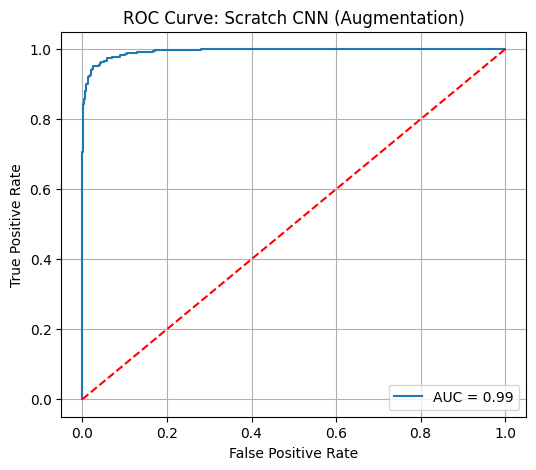

In [16]:
fpr_b, tpr_b, _ = roc_curve(y_test, test_class2_prob)
auc_b = auc(fpr_b, tpr_b)
plt.figure(figsize=(6, 5))
plt.plot(fpr_b, tpr_b, label=f'AUC = {auc_b:.2f}')
plt.plot([0, 1], [0, 1], color = 'r', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Scratch CNN (Augmentation)')
plt.legend()
plt.grid(True)
plt.show()

#<h2 style='color:#1976d2'>**Part 3: CNN + Data Augmentation, Batch Normilization, & LR Scheduling** 🧠</h2>

<h4 style="color:purple">Step 15: Model 3 — Scratch CNN + Data Augmenation, Batch Normlization, & ReduceLROnPleateu Evaluation 🔧</h4>

Builds a finalized CNN with BatchNormalization after each convolutional layer, increased Dropout rate, and a ReduceLROnPlateau callback which will reduce the learning rate as it comes closer to higher performance, then trains on augmented data and evaluates on validation and test splits

**Note:** The previous model (Model 2) had trouble stablizing and converging towards the end of the iteration of epochs, so there was an adding ReduceLROnPLateau which will reduce the learning rate in adherance to the validation set, as well as an added batch normilization to stabilize the data

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    25,690,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,756,897 (98.25 MB)

 Trainable params: 25,756,257 (98.25 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - acc: 0.8730 - loss: 0.5129
Epoch 1: val_loss improved from None to 6.02344, saving model to /content/drive/MyDrive/model_c_XRAY3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_c_XRAY3.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 92s 380ms/step - acc: 0.9055 - loss: 0.3173 - val_acc: 0.5000 - val_loss: 6.0234 - learning_rate: 5.0000e-04
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - acc: 0.9274 - loss: 0.2047
Epoch 2: val_loss improved from 6.02344 to 1.33054, saving model to /content/drive/MyDrive/model_c_XRAY3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_c_XRAY3.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 74s 346ms/step - acc: 0.9316 - loss: 0.1843 - val_acc: 0.5282 - val_loss: 1.3305 - learning_rate: 5.0000e-04
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - acc: 0.9427 - loss: 0.1672
Epoch 3: val_loss improved from 1.33054 to 0.24676, saving model to /content/drive/MyDrive/model_c_X

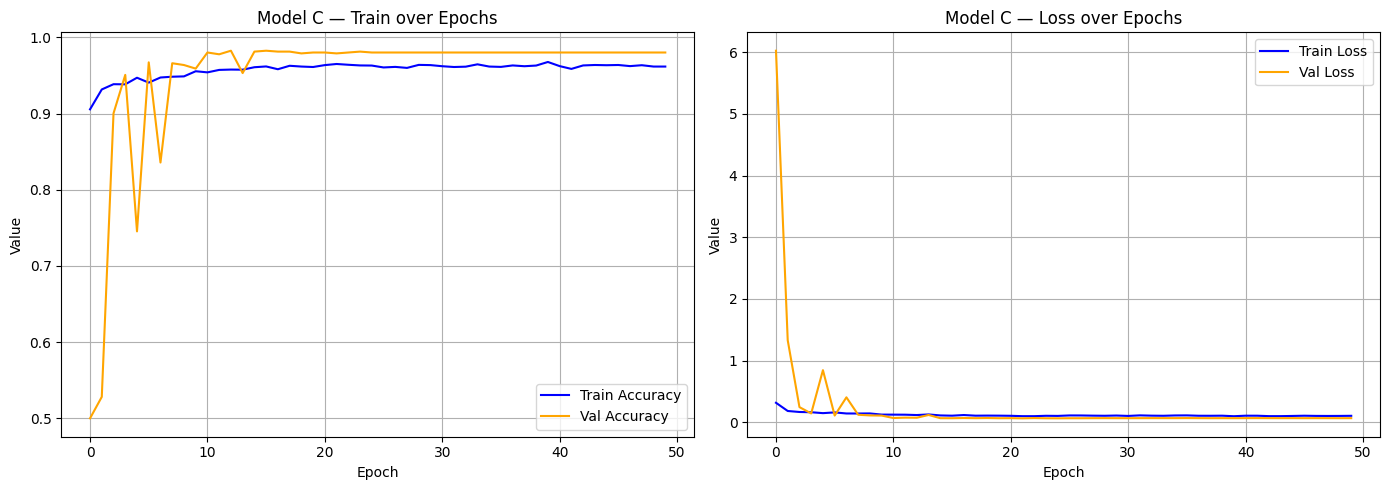

In [17]:
from keras.layers import BatchNormalization, GlobalAveragePooling2D
from keras.callbacks import ReduceLROnPlateau

#defining model 3 with batch normilization

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    patience = 3,
    min_lr = 0.000001,
    verbose = 1)

#layer 1
model_c = Sequential()
model_c.add(Conv2D(32, (3, 3), padding = 'same', use_bias=False, input_shape = x_train.shape[1:]))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(Conv2D(32, (3, 3), padding = 'same', use_bias=False))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(MaxPooling2D(pool_size=(2, 2)))
model_c.add(Dropout(0.2))

#layer 2
model_c.add(Conv2D(64, (3, 3), padding = 'same', use_bias=False))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(Conv2D(64, (3, 3), padding = 'same', use_bias=False))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(MaxPooling2D(pool_size = (2,2)))
model_c.add(Dropout(0.2))

model_c.add(Flatten())
model_c.add(Dense(128, use_bias = False))
model_c.add(BatchNormalization())
model_c.add(Dropout(0.5))
model_c.add(Dense(1))
model_c.add(Activation('sigmoid'))
#summary
model_c.summary()

save_path = '/content/drive/MyDrive/model_c_XRAY3.keras'
callbacks_save = ModelCheckpoint(save_path, monitor = 'val_loss', verbose = 1, save_best_only = True, save_freq = 'epoch')

opt = tf.keras.optimizers.Adam(learning_rate = 0.0005)
model_c.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['acc'])

history_c = model_c.fit(train_datagen.flow(x_train, y_train, batch_size=32),
                      epochs=50,
                      verbose=1,
                      validation_data=val_datagen.flow(x_val, y_val, batch_size=32),
                      callbacks=[callbacks_save, reduce_lr])

history_data = history_c.history
epochs = np.arange(len(history_data['acc']))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['acc'], color='blue', label='Train Accuracy')
plt.plot(epochs, history_data['val_acc'], color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model C — Train over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], color='blue', label='Train Loss')
plt.plot(epochs, history_data['val_loss'], color='orange', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model C — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


<h4 style="color:purple">Step 16: Model 3 — Evaluate the Model 📋</h4>

In [18]:
scorec = model_c.evaluate(x_test, y_test)
print('Total loss on test set: ', scorec[0])
print('Accuracy of test set: ', scorec[1])

score = model_c.evaluate(x_val, y_val)
print('Total loss on validation set: ', score[0])
print('Accuracy of validation set: ', score[1])

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - acc: 0.9684 - loss: 0.1016
Total loss on test set:  0.10162960737943649
Accuracy of test set:  0.9683840870857239
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9800 - loss: 0.0681
Total loss on validation set:  0.06812107563018799
Accuracy of validation set:  0.9800469279289246


<h4 style="color:purple">Step 17: Model 3 — Confusion Matrix, Accuracy, F1, Precision & Recall Scores 🎯</h4>

Assesses the batch normalization and adaptive learning rate scheduling evaluation if it further improved the NORMAL vs PNEUMONIA classification by comparing Model 3's confusion matrix and report with Model 1 and 2.



27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step

The accuracy using the testing set:  0.968384074941452

The confusion matrix using testing set: 
 [[404   4]
 [ 23 423]]


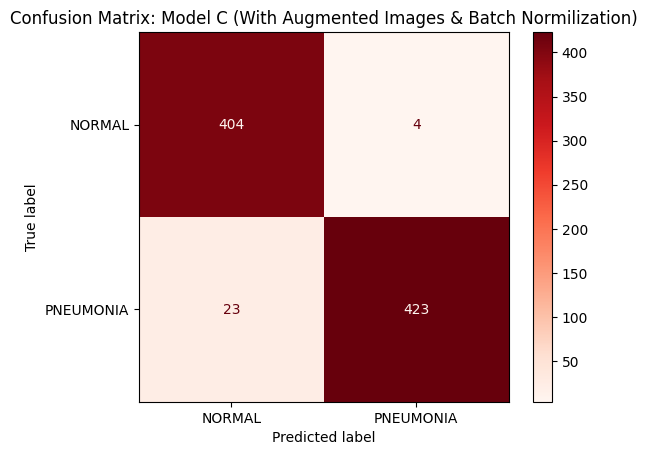


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.95      0.97       427
   PNEUMONIA       0.95      0.99      0.97       427

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [19]:
#Defining confusion matrix, F1 score & recall for model 3

test_class3_prob = model_c.predict(x_test)

test_lab3 = (test_class3_prob > 0.5).astype("int32")


print('\nThe accuracy using the testing set: ', accuracy_score(test_lab3,y_test))

conf_matx = confusion_matrix(test_lab3, y_test)
print('\nThe confusion matrix using testing set: \n', conf_matx)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matx, display_labels=classes)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix: Model C (With Augmented Images & Batch Normilization)')
plt.show()

#F1, Recall, Precision
print('\nClassification Report:')
print(classification_report(y_test, test_lab3, target_names=classes))

<h4 style="color:purple">Step 18: Model 3 — Receiver Operating Characteristic (ROC) Curve </h4>

Plots the true positive rate against the false positive rate accross the threshold to determine model capability


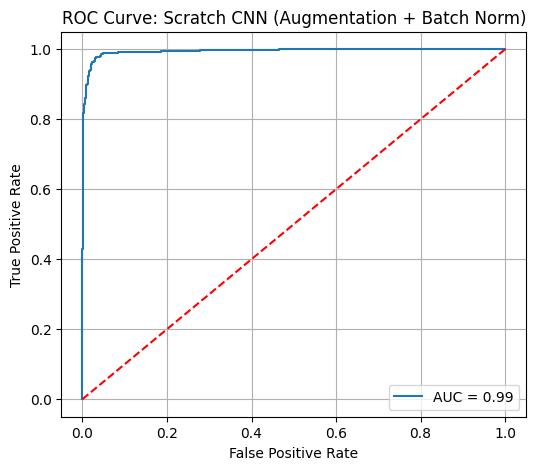

In [20]:
fpr_c, tpr_c, _ = roc_curve(y_test, test_class3_prob)
auc_c = auc(fpr_c, tpr_c)
plt.figure(figsize=(6, 5))
plt.plot(fpr_c, tpr_c, label=f'AUC = {auc_c:.2f}')
plt.plot([0, 1], [0, 1], color = 'r', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Scratch CNN (Augmentation + Batch Norm)')
plt.legend()
plt.grid(True)
plt.show()

#<h2 style='color:#1976d2'>**Part 4: Comparing Metrics** </h2>

Step 19: Compare scratch CNN vs Iterations based on metrics to determine most efficient model from evaluations.

In [21]:
results = {
    'Model': ['Scratch CNN', 'Scratch CNN (Data Augmentation)', 'Scratch CNN (Data Augmentation + Batch Normilization)'],
    'Accuracy':  [accuracy_score(y_test, test_lab),  accuracy_score(y_test, test_lab2), accuracy_score(y_test, test_lab3)],
    'Precision': [precision_score(y_test, test_lab), precision_score(y_test, test_lab2), precision_score(y_test, test_lab3)],
    'Recall':    [recall_score(y_test, test_lab),    recall_score(y_test, test_lab2), recall_score(y_test, test_lab3)],
    'F1 Score':  [f1_score(y_test, test_lab),        f1_score(y_test, test_lab2), f1_score(y_test, test_lab3)]
}

results_df = pd.DataFrame(results)
print("\nModel Metrics")
print(results_df.to_string(index=False))



Model Metrics
                                                Model  Accuracy  Precision   Recall  F1 Score
                                          Scratch CNN  0.950820   0.946636 0.955504  0.951049
                      Scratch CNN (Data Augmentation)  0.919204   0.997222 0.840749  0.912325
Scratch CNN (Data Augmentation + Batch Normilization)  0.968384   0.948430 0.990632  0.969072


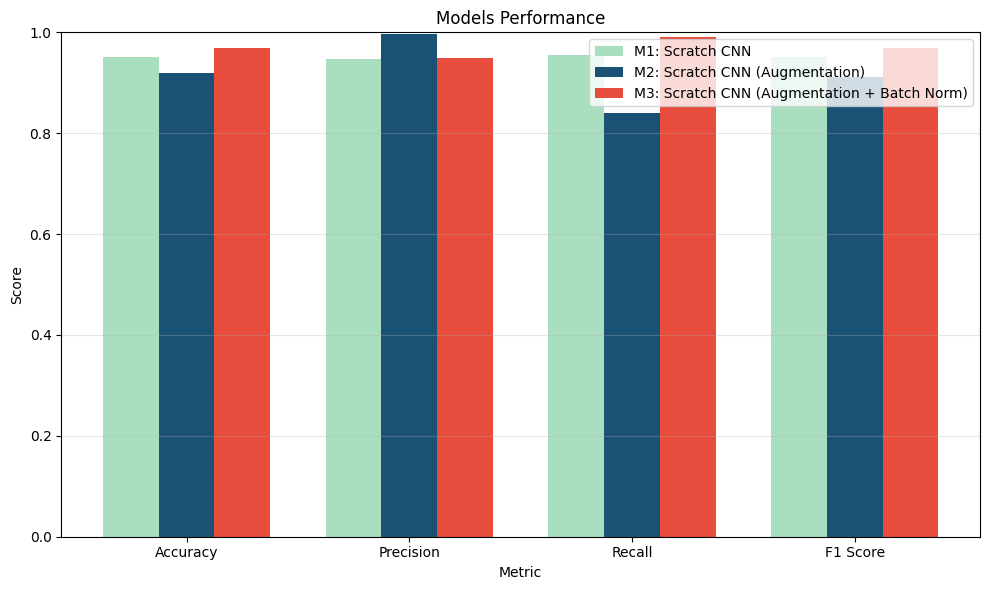

In [22]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores_a = [results[m][0] for m in metrics]
scores_b = [results[m][1] for m in metrics]
scores_c = [results[m][2] for m in metrics]

x = np.arange(len(metrics))
w = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - w, scores_a, w, label='M1: Scratch CNN', color='#a9dfbf')
plt.bar(x, scores_b, w, label='M2: Scratch CNN (Augmentation)', color='#1a5276')
plt.bar(x + w, scores_c, w, label='M3: Scratch CNN (Augmentation + Batch Norm)', color='#e74c3c')

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Models Performance')
plt.xticks(x, metrics)
plt.ylim(0, 1.00)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


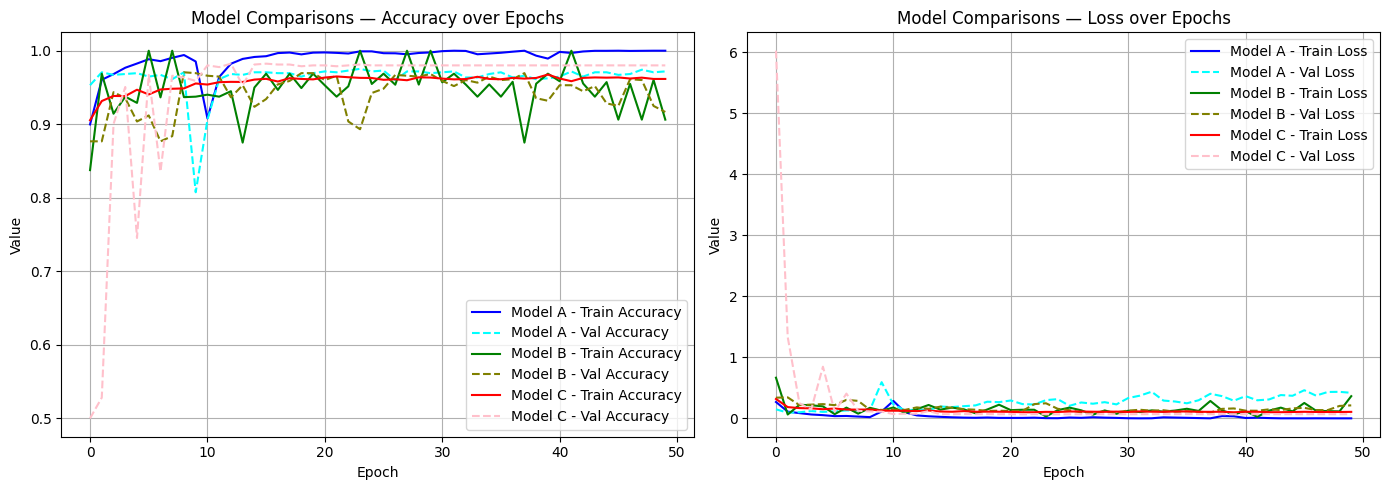

In [23]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['acc'], color='blue', label='Model A - Train Accuracy')
plt.plot(epochs, history.history['val_acc'], color='cyan', linestyle = '--', label='Model A - Val Accuracy')
plt.plot(epochs, history_b.history['acc'], color='green', label='Model B - Train Accuracy')
plt.plot(epochs, history_b.history['val_acc'], color='olive',linestyle = '--', label='Model B - Val Accuracy')
plt.plot(epochs, history_c.history['acc'], color='red', label='Model C - Train Accuracy')
plt.plot(epochs, history_c.history['val_acc'], color='pink',linestyle = '--', label='Model C - Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Comparisons — Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], color='blue', label='Model A - Train Loss')
plt.plot(epochs, history.history['val_loss'], color='cyan',linestyle = '--', label='Model A - Val Loss')
plt.plot(epochs, history_b.history['loss'], color='green', label='Model B - Train Loss')
plt.plot(epochs, history_b.history['val_loss'], color='olive',linestyle = '--', label='Model B - Val Loss')
plt.plot(epochs, history_c.history['loss'], color='red', label='Model C - Train Loss')
plt.plot(epochs, history_c.history['val_loss'], color='pink',linestyle = '--', label='Model C - Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Comparisons — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

<div style="border-radius:12px; padding: 20px; background-color: #d4edda; font-size:115%; text-align:left">

#<h2 style='color:#1976d2'>**Part 5: Conclusion 🔍** </h2>

**Step 20: Model iterations evaluation**


This project explored three iterations of convolutional nueral networks (CNN) and trained models on medical X-ray images to detect signs of pnuemonia. Such metrics were evaluated on accuracy, precision, recall, and F1 score.
Overall, the evaluations demonstrate that combining data augmentation with batch normalization produces the highest suitable CNN architecture for pneumonia classification from frontal chest X-ray images with a consistent score of 97% across all metrics. Future work may explore transfer learning approaches as well as updating to multiple classes.

</div>